In [1]:
from netgen.meshing import Mesh as NGMesh, MeshPoint, Element1D, Element0D, Pnt
from ngsolve import *

import matplotlib.pylab as plt
import numpy as np

In [2]:
def poisson_mesh(N):

    unit_interval = NGMesh(dim=1)

    pnums = []

    for i in range(N+1):
        xc = i / N
        pnums.append(unit_interval.Add(MeshPoint(Pnt(xc, 0, 0))))

    # 1D domain region
    idx_dom = unit_interval.AddRegion("omega", dim=1)
    for i in range(N):
        unit_interval.Add(Element1D([pnums[i], pnums[i+1]], index=idx_dom))

    # 0D boundary regions
    idx_left  = unit_interval.AddRegion("left", dim=0)
    idx_right = unit_interval.AddRegion("right", dim=0)

    unit_interval.Add(Element0D(pnums[0],  index=idx_left))
    unit_interval.Add(Element0D(pnums[-1], index=idx_right))

    return Mesh(unit_interval)


In [3]:
def poisson_solver(mesh):

    fes = H1(mesh, order=1, dirichlet="left|right")

    u = fes.TrialFunction()
    v = fes.TestFunction()

    f = LinearForm(fes)
    f += x*(1-x)*v*dx

    a = BilinearForm(fes)
    a += InnerProduct(grad(u), grad(v)) * dx

    a.Assemble()
    f.Assemble()

    solution_gf = GridFunction(fes)

    solution_gf.vec.data = a.mat.Inverse(fes.FreeDofs()) * f.vec

    return solution_gf

In [4]:
def error_L2(solution_gf, exact_cf):
    return sqrt(Integrate((solution_gf - exact_cf)**2, mesh))


def error_H1(error_L2, solution_gf, exact_grad_cf):
    error_H1_semi = sqrt(Integrate((grad(solution_gf) - exact_grad_cf)**2, mesh))

    return sqrt(error_L2**2 + error_H1_semi**2)

In [5]:
exact_cf = x*(x - 1)*(x*x - x - 1)/12
exact_grad_cf = exact_cf.Diff(x)

n = range(10, 10000, 200)

error_L2_vec = np.zeros(len(n))
error_H1_vec = np.zeros(len(n))
iter = 0

h = [1/i for i in n]

for N in n:
    mesh = poisson_mesh(N)
    solution_gf = poisson_solver(mesh)
    error_L2_vec[iter] = error_L2(solution_gf, exact_cf)
    error_H1_vec[iter] = error_H1(error_L2_vec[iter], solution_gf, exact_grad_cf)
    
    iter +=1

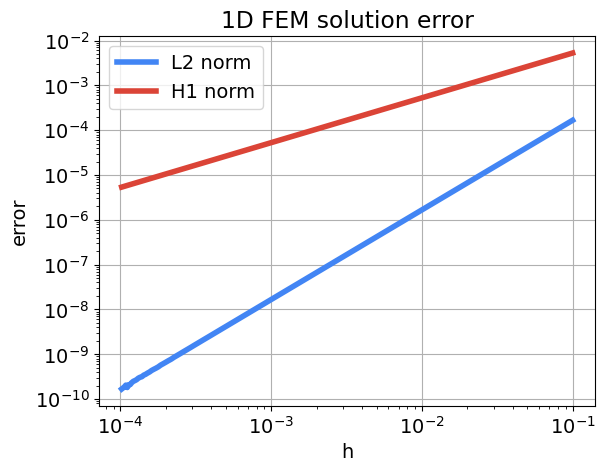

In [6]:
plt.rcParams.update({'font.size': 14})

plt.loglog(h, error_L2_vec, linewidth=4, color='#4285F4', label="L2 norm")
plt.loglog(h, error_H1_vec, linewidth=4, color='#DB4437', label="H1 norm")
plt.xlabel("h")
plt.ylabel("error")
plt.title("1D FEM solution error")
plt.grid()
plt.legend()
plt.legend(frameon=True)
plt.show()